# Total Greeks Hedge

## Libraries Import

In [79]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')

from src.config_loader import load_config
from src.stochastic_engines import GBMModel, MertonJumpDiffusion
from src.analytics import (
    bsm_price,
    bsm_delta,
    bsm_gamma,
    bsm_vega,
    bsm_theta,
)

np.set_printoptions(suppress=True, precision=6)

## Market Configuration

In [80]:
config = load_config()

config.market = config.market_params
config.merton = config.merton_params
config.sim = config.simulation

r = float(config.market.r)
sigma_bsm = float(config.market.sigma)
dt = float(config.market.dt)
S0 = float(config.market.S0)

hedge_T = 10.0  # Hedge horizon
n_steps = int(round(hedge_T / dt))
t_grid = np.arange(n_steps + 1) * dt

def _truncate_paths(paths: np.ndarray, n_steps: int) -> np.ndarray:
    return np.asarray(paths[:, : n_steps + 1], dtype=float)

print(f"dt={dt:.6f}, hedge_T={hedge_T}, n_steps={n_steps}, n_paths={config.sim.n_paths}")

dt=0.003968, hedge_T=10.0, n_steps=2520, n_paths=10000


## Loading Simulation

In [81]:
from pathlib import Path

# Paths access
paths_file = Path("..") / "data" / "simulated_paths.npz"

if paths_file.exists():
    data = np.load(paths_file)
    gbm_paths_full = np.asarray(data["gbm"], dtype=float)
    mjd_paths_full = np.asarray(data["merton"], dtype=float)

    # Error if dt mismatch
    dt_file = float(data.get("dt", dt))
    if not np.isclose(dt_file, dt):
        print(f"Warning: dt in file ({dt_file}) != config dt ({dt}).")

    print(f"Loaded simulated paths from {paths_file.resolve()}")
else:
    print(f"Paths file not found at {paths_file.resolve()}, generating paths.")
    gbm_paths_full = GBMModel(config).generate_paths()
    mjd_paths_full = MertonJumpDiffusion(config).generate_paths()

# Truncation to hedge horizon
gbm_paths = _truncate_paths(gbm_paths_full, n_steps=n_steps)
mjd_paths = _truncate_paths(mjd_paths_full, n_steps=n_steps)

assert gbm_paths.shape == mjd_paths.shape
print("paths shape:", gbm_paths.shape)

Loaded simulated paths from /home/mattia/Coding/delta-hedging-in-merton-jump-diffusion-model/data/simulated_paths.npz
paths shape: (10000, 2521)


## Volatility Skew

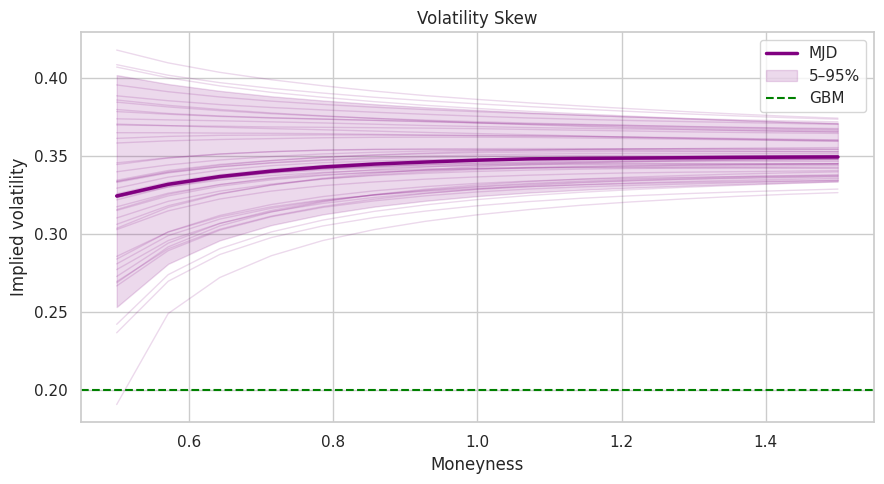

In [82]:
from scipy.optimize import brentq

T_smile = hedge_T
S0_smile = S0
r_smile = r

K_grid = np.linspace(0.5 * S0_smile, 1.5 * S0_smile, 15)
ST_mjd = mjd_paths[:, -1]
discount = np.exp(-r_smile * T_smile)

def implied_vol(price, S, K, T, r, option_type="call", tol=1e-6):
    if price <= 0.0:
        return np.nan

    def _f(sigma):
        return bsm_price(S, K, T, r, sigma, option_type=option_type) - price

    try:
        return brentq(_f, 1e-4, 5.0, xtol=tol)
    except ValueError:
        return np.nan

def skew_from_sample(ST_sample):
    prices = []
    for K in K_grid:
        payoff = np.maximum(ST_sample - K, 0.0)
        prices.append(discount * np.mean(payoff))
    prices = np.asarray(prices, dtype=float)
    iv = np.array([
        implied_vol(p, S0_smile, K, T_smile, r_smile)
        for p, K in zip(prices, K_grid)
    ])
    return iv

# Skew from terminal distribution
rng = np.random.default_rng(123)
n_paths = ST_mjd.shape[0]
n_boot = 50
boot_iv = []

plt.figure(figsize=(9, 5))

for b in range(n_boot):
    idx = rng.choice(n_paths, size=n_paths, replace=True)
    iv = skew_from_sample(ST_mjd[idx])
    boot_iv.append(iv)
    plt.plot(K_grid / S0_smile, iv, color="purple", alpha=0.15, lw=1)

boot_iv = np.asarray(boot_iv)
iv_med = np.nanmedian(boot_iv, axis=0)
iv_p05 = np.nanpercentile(boot_iv, 5, axis=0)
iv_p95 = np.nanpercentile(boot_iv, 95, axis=0)

plt.plot(K_grid / S0_smile, iv_med, color="purple", lw=2.5, label="MJD")
plt.fill_between(K_grid / S0_smile, iv_p05, iv_p95, color="purple", alpha=0.15, label="5–95%")

plt.axhline(sigma_bsm, linestyle="--", label="GBM", color="green")
plt.xlabel("Moneyness")
plt.ylabel("Implied volatility")
plt.title("Volatility Skew")
plt.legend()
plt.tight_layout()
plt.show()

## Hedging Contract

In [ ]:
K0 = S0
K1 = 0.9 * S0
K2 = 1.1 * S0

# Hedged option type
option_type = "put"

K0, K1, K2

(100.0, 90.0, 110.00000000000001)

## Total-Greeks Hedge Engine

In [84]:
def time_to_maturity_grid(T: float, dt: float, n_steps: int) -> np.ndarray:
    tau = T - np.arange(n_steps + 1) * dt
    return np.maximum(tau, 0.0)


tau_grid = time_to_maturity_grid(hedge_T, dt=dt, n_steps=n_steps)


def _bsm_all(S: np.ndarray, K: float, tau: float, r: float, sigma: float, option_type: str = "call"):
    price = bsm_price(S, K, tau, r, sigma, option_type=option_type)
    delta = bsm_delta(S, K, tau, r, sigma, option_type=option_type)
    gamma = bsm_gamma(S, K, tau, r, sigma)
    vega = bsm_vega(S, K, tau, r, sigma)
    theta = bsm_theta(S, K, tau, r, sigma, option_type=option_type)
    return price, delta, gamma, vega, theta


def solve_total_greeks_hedge(
    S: np.ndarray,
    tau: float,
    *,
    r: float,
    sigma: float,
    K0: float,
    K1: float,
    K2: float,
    option_type: str = "call",
    ridge: float = 1e-12,
) -> dict:
    
    S = np.asarray(S, dtype=float)

    C0, D0, G0, V0, Th0 = _bsm_all(S, K0, tau, r, sigma, option_type=option_type)
    C1, D1, G1, V1, Th1 = _bsm_all(S, K1, tau, r, sigma, option_type=option_type)
    C2, D2, G2, V2, Th2 = _bsm_all(S, K2, tau, r, sigma, option_type=option_type)

    det = G1 * V2 - G2 * V1

    # Determinant stabilizer when det is close to zero
    det_safe = det + ridge * np.where(det >= 0, 1.0, -1.0)

    x1 = (G0 * V2 - G2 * V0) / det_safe
    x2 = (G1 * V0 - G0 * V1) / det_safe
    xS = D0 - x1 * D1 - x2 * D2

    return {
        "C0": C0,
        "C1": C1,
        "C2": C2,
        "D0": D0,
        "D1": D1,
        "D2": D2,
        "G0": G0,
        "G1": G1,
        "G2": G2,
        "V0": V0,
        "V1": V1,
        "V2": V2,
        "Th0": Th0,
        "Th1": Th1,
        "Th2": Th2,
        "x1": x1,
        "x2": x2,
        "xS": xS,
        "det_GV": det,
    }


def run_self_financing_hedge(
    paths: np.ndarray,
    *,
    r: float,
    sigma: float,
    dt: float,
    tau_grid: np.ndarray,
    K0: float,
    K1: float,
    K2: float,
    option_type: str = "call",
    ridge: float = 1e-12,
) -> dict:
    
    paths = np.asarray(paths, dtype=float)
    n_paths, n_steps_plus_1 = paths.shape
    n_steps = n_steps_plus_1 - 1

    assert tau_grid.shape[0] == n_steps_plus_1

    # Allocating arrays
    xS = np.zeros((n_paths, n_steps_plus_1))
    x1 = np.zeros((n_paths, n_steps_plus_1))
    x2 = np.zeros((n_paths, n_steps_plus_1))
    B = np.zeros((n_paths, n_steps_plus_1))

    C0 = np.zeros((n_paths, n_steps_plus_1))
    C1 = np.zeros((n_paths, n_steps_plus_1))
    C2 = np.zeros((n_paths, n_steps_plus_1))

    # Pre-rebalancing net exposures
    net_delta_pre = np.full((n_paths, n_steps_plus_1), np.nan)
    net_gamma_pre = np.full((n_paths, n_steps_plus_1), np.nan)

    # Stepwise PnL components
    pnl_stock = np.zeros((n_paths, n_steps))
    pnl_opt1 = np.zeros((n_paths, n_steps))
    pnl_opt2 = np.zeros((n_paths, n_steps))
    pnl_cash = np.zeros((n_paths, n_steps))
    pnl_liability = np.zeros((n_paths, n_steps))
    pnl_hedged = np.zeros((n_paths, n_steps))

    # Initial hedge
    S0_vec = paths[:, 0]
    tau0 = float(tau_grid[0])
    st0 = solve_total_greeks_hedge(
        S0_vec,
        tau0,
        r=r,
        sigma=sigma,
        K0=K0,
        K1=K1,
        K2=K2,
        option_type=option_type,
        ridge=ridge,
    )

    xS[:, 0] = st0["xS"]
    x1[:, 0] = st0["x1"]
    x2[:, 0] = st0["x2"]

    C0[:, 0] = st0["C0"]
    C1[:, 0] = st0["C1"]
    C2[:, 0] = st0["C2"]

    # Initial portfolio value
    B[:, 0] = C0[:, 0] - xS[:, 0] * S0_vec - x1[:, 0] * C1[:, 0] - x2[:, 0] * C2[:, 0]

    # Iteration
    growth = float(np.exp(r * dt))
    for i in range(n_steps):
        S_i = paths[:, i]
        S_ip1 = paths[:, i + 1]
        tau_i = float(tau_grid[i])
        tau_ip1 = float(tau_grid[i + 1])

        # Current prices
        if i > 0:
            C0[:, i], _, _, _, _ = _bsm_all(S_i, K0, tau_i, r, sigma, option_type=option_type)
            C1[:, i], _, _, _, _ = _bsm_all(S_i, K1, tau_i, r, sigma, option_type=option_type)
            C2[:, i], _, _, _, _ = _bsm_all(S_i, K2, tau_i, r, sigma, option_type=option_type)

        # Next prices
        C0_ip1, D0_ip1, G0_ip1, _, _ = _bsm_all(S_ip1, K0, tau_ip1, r, sigma, option_type=option_type)
        C1_ip1, D1_ip1, G1_ip1, _, _ = _bsm_all(S_ip1, K1, tau_ip1, r, sigma, option_type=option_type)
        C2_ip1, D2_ip1, G2_ip1, _, _ = _bsm_all(S_ip1, K2, tau_ip1, r, sigma, option_type=option_type)

        # Profits and losses
        pnl_stock[:, i] = xS[:, i] * (S_ip1 - S_i)
        pnl_opt1[:, i] = x1[:, i] * (C1_ip1 - C1[:, i])
        pnl_opt2[:, i] = x2[:, i] * (C2_ip1 - C2[:, i])
        pnl_cash[:, i] = B[:, i] * (growth - 1.0)
        pnl_liability[:, i] = (C0_ip1 - C0[:, i])

        pnl_hedged[:, i] = pnl_stock[:, i] + pnl_opt1[:, i] + pnl_opt2[:, i] + pnl_cash[:, i] - pnl_liability[:, i]

        # Portfolio value before re-hedging
        V_pre = (
            xS[:, i] * S_ip1
            + x1[:, i] * C1_ip1
            + x2[:, i] * C2_ip1
            + B[:, i] * growth
        )

        # Exposures before re-hedging
        net_delta_pre[:, i + 1] = xS[:, i] + x1[:, i] * D1_ip1 + x2[:, i] * D2_ip1 - D0_ip1
        net_gamma_pre[:, i + 1] = x1[:, i] * G1_ip1 + x2[:, i] * G2_ip1 - G0_ip1

        # Re-hedging
        st = solve_total_greeks_hedge(
            S_ip1,
            tau_ip1,
            r=r,
            sigma=sigma,
            K0=K0,
            K1=K1,
            K2=K2,
            option_type=option_type,
            ridge=ridge,
        )

        xS[:, i + 1] = st["xS"]
        x1[:, i + 1] = st["x1"]
        x2[:, i + 1] = st["x2"]

        C0[:, i + 1] = st["C0"]
        C1[:, i + 1] = st["C1"]
        C2[:, i + 1] = st["C2"]

        # Portfolio value after re-hedging
        B[:, i + 1] = V_pre - xS[:, i + 1] * S_ip1 - x1[:, i + 1] * C1_ip1 - x2[:, i + 1] * C2_ip1

    # Terminal portfolio value
    V = xS * paths + x1 * C1 + x2 * C2 + B
    hedge_error = V - C0

    # Terminal error vs payoff
    payoff = np.maximum(paths[:, -1] - K0, 0.0) if option_type == "call" else np.maximum(K0 - paths[:, -1], 0.0)
    terminal_error_vs_payoff = V[:, -1] - payoff

    return {
        "paths": paths,
        "V": V,
        "C0": C0,
        "C1": C1,
        "C2": C2,
        "xS": xS,
        "x1": x1,
        "x2": x2,
        "B": B,
        "hedge_error": hedge_error,
        "terminal_error_vs_payoff": terminal_error_vs_payoff,
        "pnl_stock": pnl_stock,
        "pnl_opt1": pnl_opt1,
        "pnl_opt2": pnl_opt2,
        "pnl_cash": pnl_cash,
        "pnl_liability": pnl_liability,
        "pnl_hedged": pnl_hedged,
        "net_delta_pre": net_delta_pre,
        "net_gamma_pre": net_gamma_pre,
    }


def summarize_terminal_error(err_T: np.ndarray) -> pd.Series:
    err_T = np.asarray(err_T, dtype=float)
    return pd.Series({
        "mean": float(np.mean(err_T)),
        "std": float(np.std(err_T, ddof=1)),
        "rmse": float(np.sqrt(np.mean(err_T**2))),
        "q01": float(np.quantile(err_T, 0.01)),
        "q05": float(np.quantile(err_T, 0.05)),
        "q50": float(np.quantile(err_T, 0.50)),
        "q95": float(np.quantile(err_T, 0.95)),
        "q99": float(np.quantile(err_T, 0.99)),
    })

### Run hedges under GBM vs Merton jump-diffusion and summarize terminal error

In [ ]:
gbm_res = run_self_financing_hedge(
    gbm_paths,
    r=r,
    sigma=sigma_bsm,
    dt=dt,
    tau_grid=tau_grid,
    K0=K0,
    K1=K1,
    K2=K2,
    option_type=option_type,
)

mjd_res = run_self_financing_hedge(
    mjd_paths,
    r=r,
    sigma=sigma_bsm,
    dt=dt,
    tau_grid=tau_grid,
    K0=K0,
    K1=K1,
    K2=K2,
    option_type=option_type,
)

gbm_term = gbm_res["terminal_error_vs_payoff"]
mjd_term = mjd_res["terminal_error_vs_payoff"]

summary = pd.DataFrame({
    "GBM": summarize_terminal_error(gbm_term),
    "MertonJD": summarize_terminal_error(mjd_term),
})

summary

## Hedge error (time series + terminal distribution)

We report hedge error both as:
- **mark-to-model**: \(E_t = V_t - C_0(S_t,\tau_t)\)
- **terminal vs payoff**: \(V_T - \text{payoff}\) (this is the economically relevant replication error)

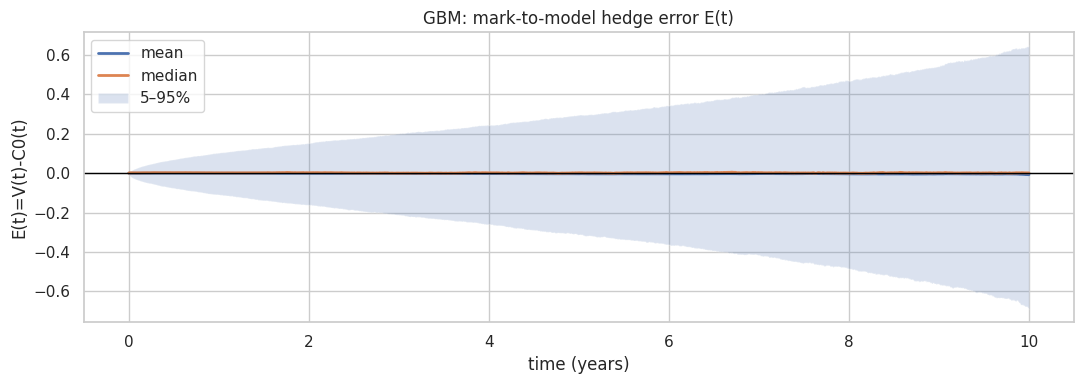

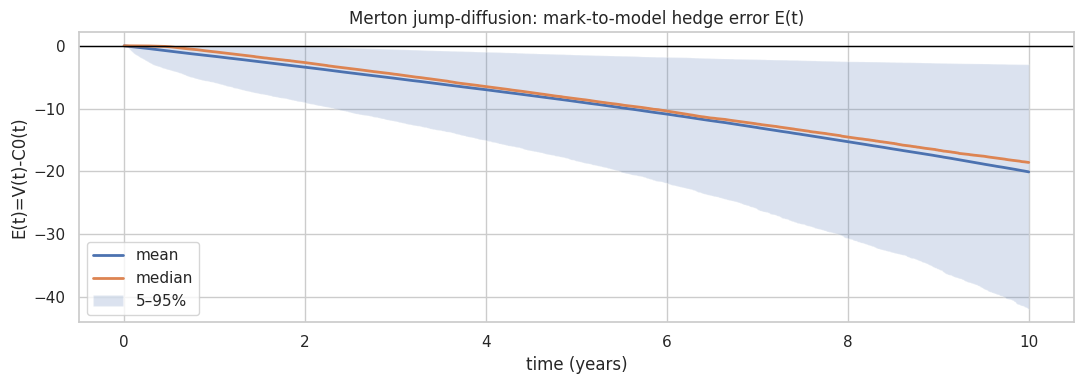

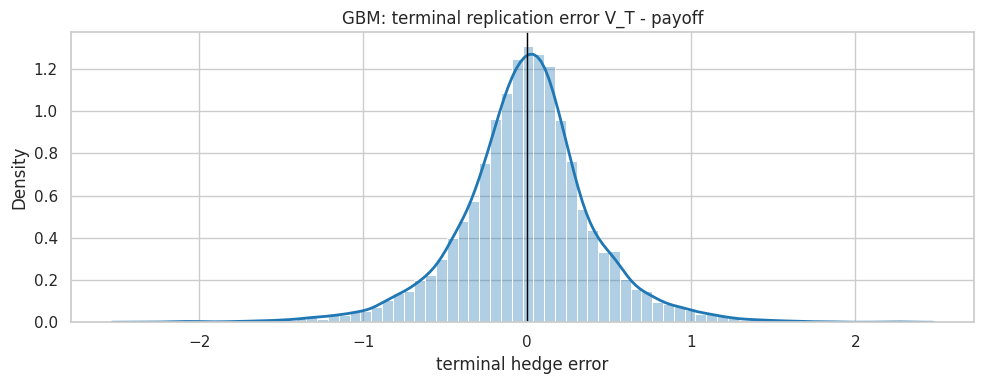

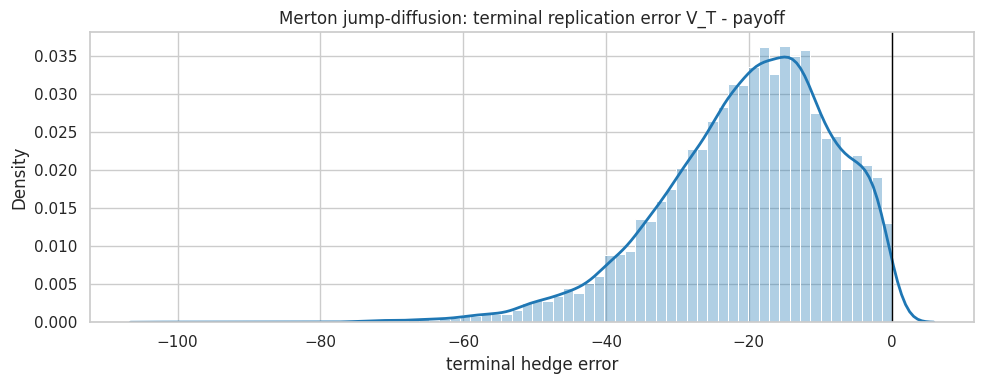

In [86]:
def plot_error_timeseries(res: dict, title: str, *, t_grid: np.ndarray):
    E = res["hedge_error"]
    q = np.quantile(E, [0.05, 0.5, 0.95], axis=0)
    mean = E.mean(axis=0)

    plt.figure(figsize=(11, 4))
    plt.plot(t_grid, mean, lw=2.0, label="mean")
    plt.plot(t_grid, q[1], lw=2.0, label="median")
    plt.fill_between(t_grid, q[0], q[2], alpha=0.2, label="5–95%")
    plt.axhline(0.0, color="black", lw=1)
    plt.title(title)
    plt.xlabel("time (years)")
    plt.ylabel("E(t)=V(t)-C0(t)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_terminal_distribution(err_T: np.ndarray, title: str):
    err_T = np.asarray(err_T, dtype=float)
    plt.figure(figsize=(10, 4))
    sns.histplot(err_T, bins=70, stat="density", color="tab:blue", alpha=0.35)
    sns.kdeplot(err_T, color="tab:blue", lw=2)
    plt.axvline(0.0, color="black", lw=1)
    plt.title(title)
    plt.xlabel("terminal hedge error")
    plt.tight_layout()
    plt.show()


plot_error_timeseries(gbm_res, "GBM: mark-to-model hedge error E(t)", t_grid=t_grid)
plot_error_timeseries(mjd_res, "Merton jump-diffusion: mark-to-model hedge error E(t)", t_grid=t_grid)

plot_terminal_distribution(gbm_term, "GBM: terminal replication error V_T - payoff")
plot_terminal_distribution(mjd_term, "Merton jump-diffusion: terminal replication error V_T - payoff")

## PnL attribution and distributions

We compute stepwise hedged PnL increment
\[
\Delta \Pi_{i,i+1} = \Delta V_{i,i+1} - \Delta C_{0,i,i+1}
\]
where \(V\) is the self-financing replication portfolio.

We attribute \(\Delta V\) into stock/option/cash components and visualize:
- the **total hedged PnL distribution**
- the **residual** spikes induced by jumps (in the jump-diffusion case)

In [87]:
def pnl_summary(res: dict) -> pd.Series:
    pnl_T = res["pnl_hedged"].sum(axis=1)
    return pd.Series({
        "mean": float(pnl_T.mean()),
        "std": float(pnl_T.std(ddof=1)),
        "rmse": float(np.sqrt(np.mean(pnl_T**2))),
        "q01": float(np.quantile(pnl_T, 0.01)),
        "q05": float(np.quantile(pnl_T, 0.05)),
        "q50": float(np.quantile(pnl_T, 0.50)),
        "q95": float(np.quantile(pnl_T, 0.95)),
        "q99": float(np.quantile(pnl_T, 0.99)),
    })


gbm_pnl_s = pnl_summary(gbm_res)
mjd_pnl_s = pnl_summary(mjd_res)

pd.DataFrame({"GBM": gbm_pnl_s, "MertonJD": mjd_pnl_s})

,GBM,MertonJD
mean,-0.007565,-20.077069
std,0.411245,12.099838
rmse,0.411294,23.440993
q01,-1.165176,-55.599358
q05,-0.689417,-41.911337
q50,0.001575,-18.566872
q95,0.647542,-2.933856
q99,1.090762,-0.853751


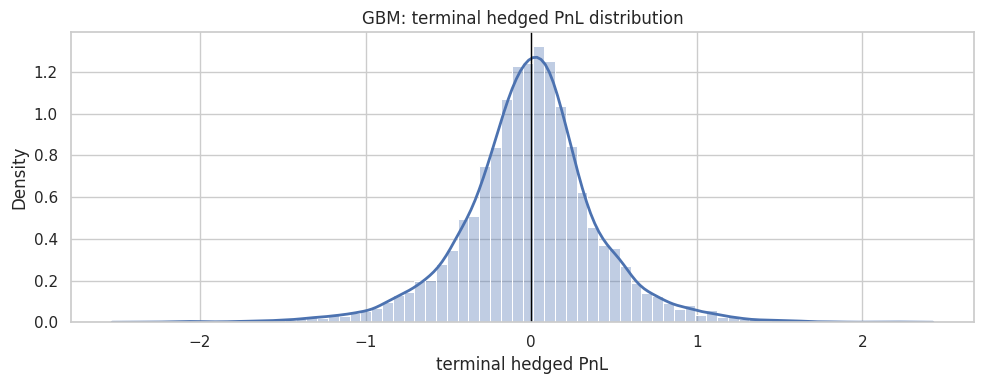

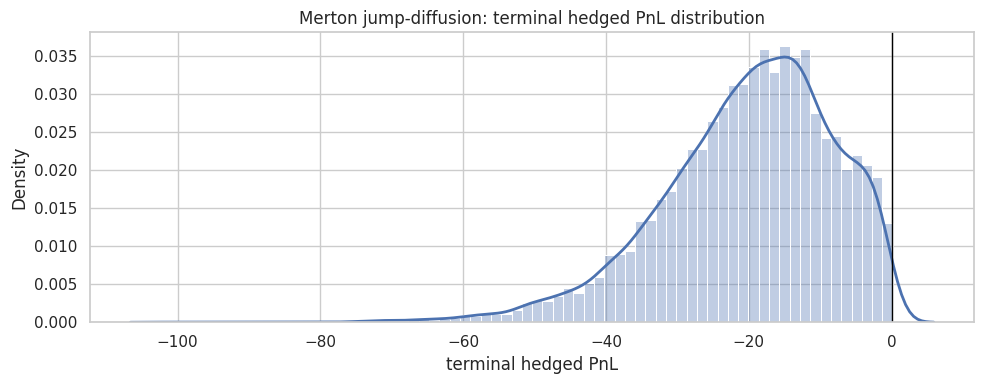

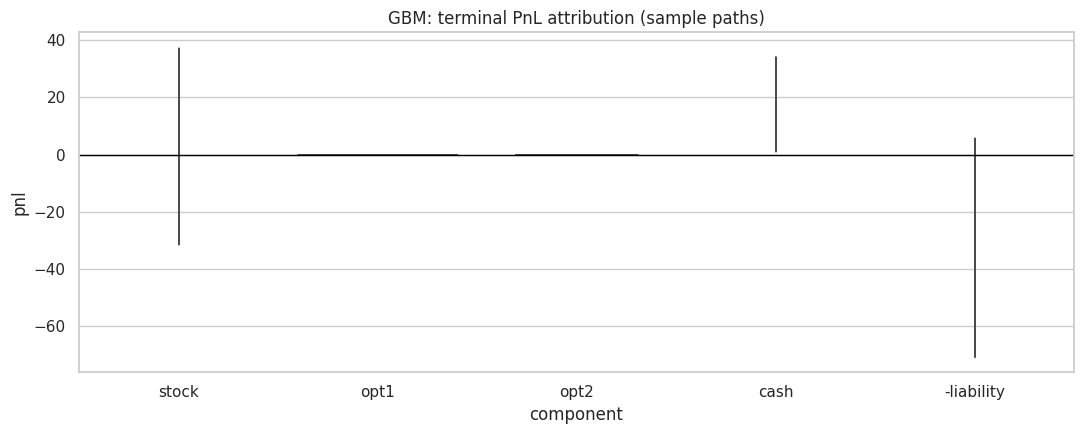

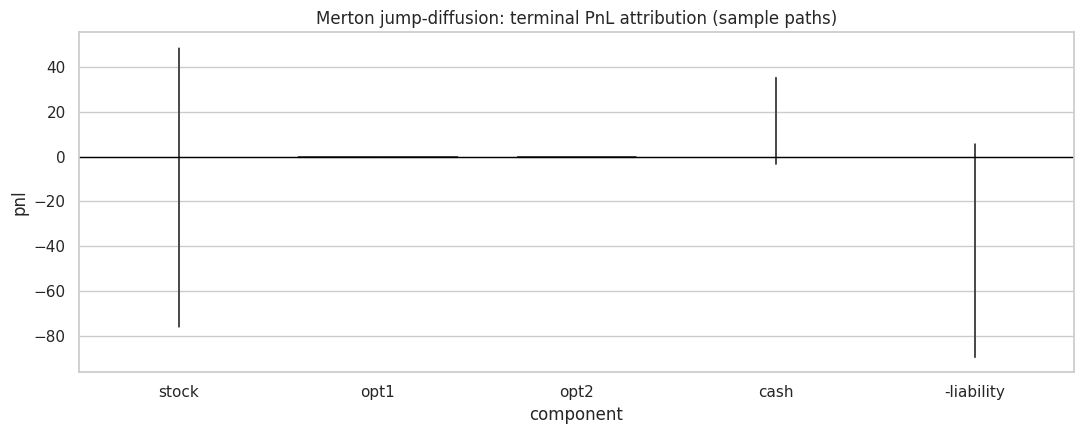

In [88]:
def plot_pnl_distribution(res: dict, title: str):
    pnl_T = res["pnl_hedged"].sum(axis=1)
    plt.figure(figsize=(10, 4))
    sns.histplot(pnl_T, bins=70, stat="density", alpha=0.35)
    sns.kdeplot(pnl_T, lw=2)
    plt.axvline(0.0, color="black", lw=1)
    plt.title(title)
    plt.xlabel("terminal hedged PnL")
    plt.tight_layout()
    plt.show()


def plot_attribution_stacked(res: dict, title: str, *, n_paths_plot: int = 200):
    rng = np.random.default_rng(123)
    n_paths = res["pnl_hedged"].shape[0]
    idx = rng.choice(n_paths, size=min(n_paths_plot, n_paths), replace=False)

    # terminal attribution components
    stock = res["pnl_stock"][idx].sum(axis=1)
    opt1 = res["pnl_opt1"][idx].sum(axis=1)
    opt2 = res["pnl_opt2"][idx].sum(axis=1)
    cash = res["pnl_cash"][idx].sum(axis=1)
    liab = -res["pnl_liability"][idx].sum(axis=1)  # subtracting liability PnL

    df = pd.DataFrame({
        "stock": stock,
        "opt1": opt1,
        "opt2": opt2,
        "cash": cash,
        "-liability": liab,
    })

    # show distribution of each component
    plt.figure(figsize=(11, 4.5))
    df_melt = df.melt(var_name="component", value_name="pnl")
    sns.violinplot(data=df_melt, x="component", y="pnl", inner="quartile", cut=0)
    plt.title(title)
    plt.axhline(0.0, color="black", lw=1)
    plt.tight_layout()
    plt.show()


plot_pnl_distribution(gbm_res, "GBM: terminal hedged PnL distribution")
plot_pnl_distribution(mjd_res, "Merton jump-diffusion: terminal hedged PnL distribution")

plot_attribution_stacked(gbm_res, "GBM: terminal PnL attribution (sample paths)")
plot_attribution_stacked(mjd_res, "Merton jump-diffusion: terminal PnL attribution (sample paths)")

## Portfolio value paths

We plot sample paths of the **replicating portfolio value** \(V_t\) vs the model price \(C_0(S_t,\tau_t)\).

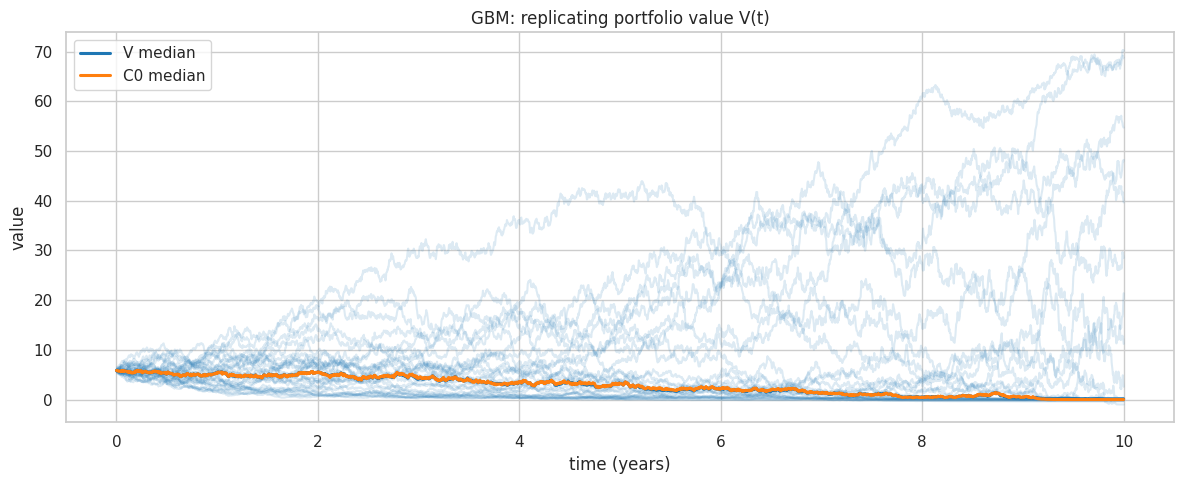

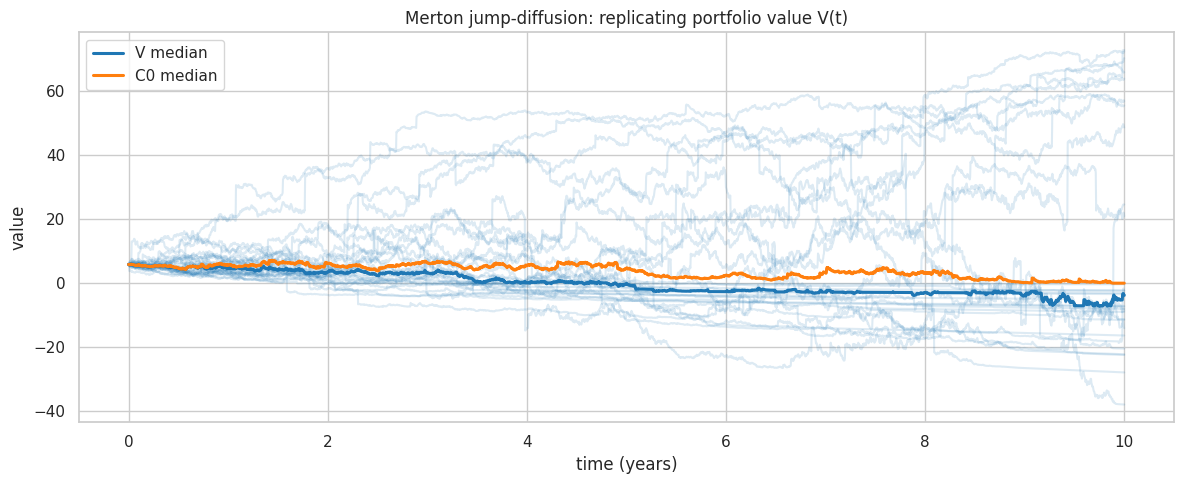

In [89]:
def plot_portfolio_paths(res: dict, title: str, *, t_grid: np.ndarray, n_plot: int = 30, seed: int = 0):
    rng = np.random.default_rng(seed)
    n_paths = res["V"].shape[0]
    idx = rng.choice(n_paths, size=min(n_plot, n_paths), replace=False)

    V = res["V"][idx]
    C0 = res["C0"][idx]

    plt.figure(figsize=(12, 5))
    for j in range(V.shape[0]):
        plt.plot(t_grid, V[j], color="tab:blue", alpha=0.15)
    plt.plot(t_grid, np.median(V, axis=0), color="tab:blue", lw=2.2, label="V median")

    # show median model price too
    plt.plot(t_grid, np.median(C0, axis=0), color="tab:orange", lw=2.2, label="C0 median")

    plt.title(title)
    plt.xlabel("time (years)")
    plt.ylabel("value")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_portfolio_paths(gbm_res, "GBM: replicating portfolio value V(t)", t_grid=t_grid, seed=1)
plot_portfolio_paths(mjd_res, "Merton jump-diffusion: replicating portfolio value V(t)", t_grid=t_grid, seed=2)

## Delta / Gamma exposure plots

By construction, exposures are neutralized **at each rebalance time**. The relevant diagnostic for jump failure is the **pre-rebalance exposure** at \(t_{i+1}\) using the **old holdings** (i.e., after the price move, before you can trade). We plot average absolute pre-rebalance delta/gamma exposure through time.

/home/mattia/Coding/delta-hedging-in-merton-jump-diffusion-model/.venv/lib64/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


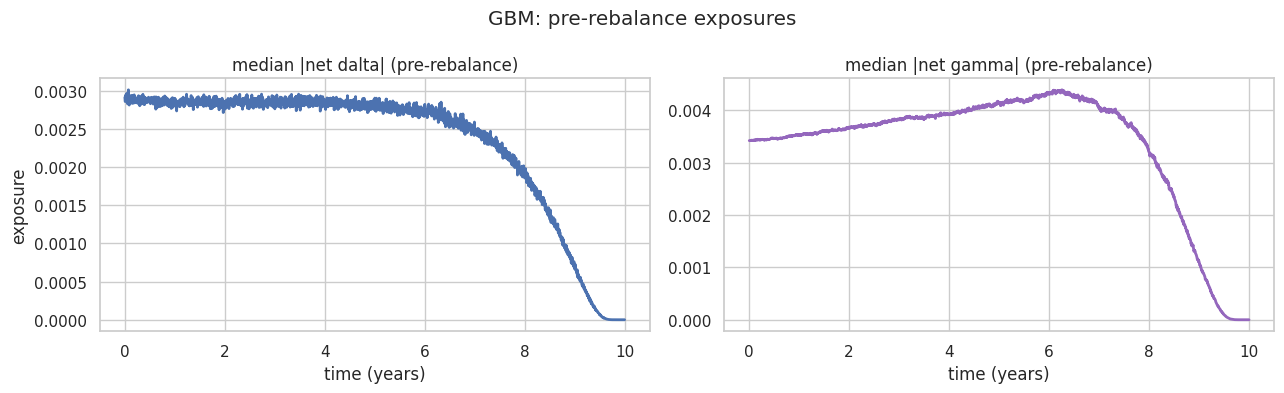

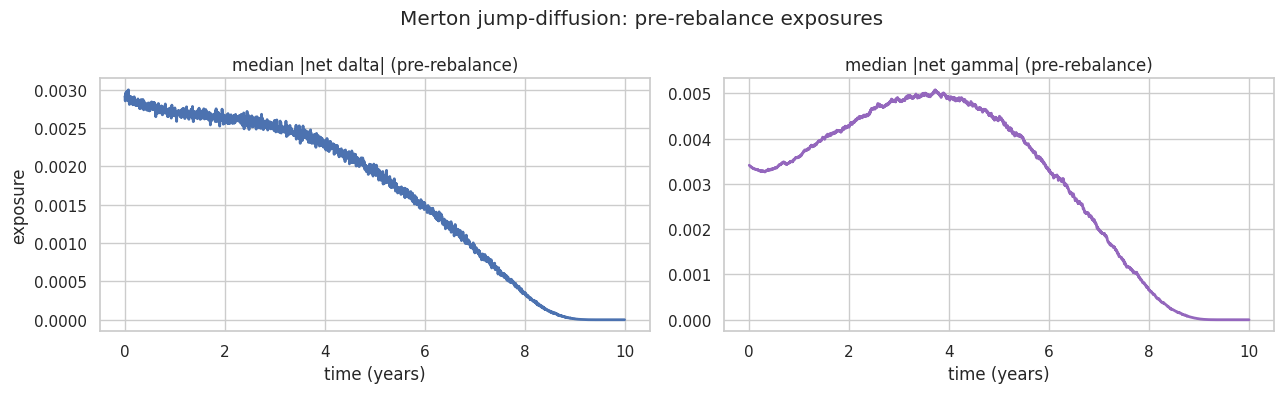

In [90]:
def plot_exposure(res: dict, title: str, *, t_grid: np.ndarray):
    d = res["net_delta_pre"]
    g = res["net_gamma_pre"]

    # robust average (median abs)
    d_medabs = np.nanmedian(np.abs(d), axis=0)
    g_medabs = np.nanmedian(np.abs(g), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    axes[0].plot(t_grid, d_medabs, lw=2)
    axes[0].set_title("median |net dalta| (pre-rebalance)")
    axes[0].set_xlabel("time (years)")
    axes[0].set_ylabel("exposure")

    axes[1].plot(t_grid, g_medabs, lw=2, color="tab:purple")
    axes[1].set_title("median |net gamma| (pre-rebalance)")
    axes[1].set_xlabel("time (years)")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_exposure(gbm_res, "GBM: pre-rebalance exposures", t_grid=t_grid)
plot_exposure(mjd_res, "Merton jump-diffusion: pre-rebalance exposures", t_grid=t_grid)

## Side-by-side comparison (tables)

We compare:
- terminal replication error vs payoff
- terminal hedged PnL (sum of stepwise hedged PnL increments)

and summarize key risk statistics (std, RMSE, tail quantiles).

In [91]:
comparison = pd.concat(
    [
        summary.T.add_prefix("err_"),
        pd.DataFrame({
            "pnl_mean": [gbm_pnl_s["mean"], mjd_pnl_s["mean"]],
            "pnl_std": [gbm_pnl_s["std"], mjd_pnl_s["std"]],
            "pnl_rmse": [gbm_pnl_s["rmse"], mjd_pnl_s["rmse"]],
            "pnl_q01": [gbm_pnl_s["q01"], mjd_pnl_s["q01"]],
            "pnl_q05": [gbm_pnl_s["q05"], mjd_pnl_s["q05"]],
            "pnl_q50": [gbm_pnl_s["q50"], mjd_pnl_s["q50"]],
            "pnl_q95": [gbm_pnl_s["q95"], mjd_pnl_s["q95"]],
            "pnl_q99": [gbm_pnl_s["q99"], mjd_pnl_s["q99"],],
        }, index=["GBM", "MertonJD"]),
    ],
    axis=1,
)

comparison

,err_mean,err_std,err_rmse,err_q01,err_q05,err_q50,err_q95,err_q99,pnl_mean,pnl_std,pnl_rmse,pnl_q01,pnl_q05,pnl_q50,pnl_q95,pnl_q99
GBM,-0.007947,0.411933,0.411989,-1.168152,-0.690718,0.000967,0.647922,1.093230,-0.007565,0.411245,0.411294,-1.165176,-0.689417,0.001575,0.647542,1.090762
MertonJD,-20.078319,12.100079,23.442188,-55.561839,-41.914536,-18.569249,-2.933856,-0.853751,-20.077069,12.099838,23.440993,-55.599358,-41.911337,-18.566872,-2.933856,-0.853751


## Why it fails under jumps (what to look for)

- In **GBM**, price moves are continuous. A Δ–Γ–V hedge built from BSM greeks is locally accurate, so as `dt` becomes small the terminal replication error shrinks.
- In **Merton jump-diffusion**, jumps create **discontinuous** moves. Between rebalances you cannot trade, so the portfolio is exposed to the jump via the **pre-rebalance exposures** and the hedge error develops heavy tails.

You should see:
- much wider terminal error / PnL distributions for Merton
- exposure spikes (pre-rebalance) around jump times
- a big increase in **std** and **RMSE** of terminal replication error

In [92]:
# Optional: quick visual of how jump days drive hedged PnL (diagnostic)
# We flag large absolute log-returns as a proxy for jump steps.

def jump_proxy_steps(paths: np.ndarray, threshold_sigma: float = 4.0) -> np.ndarray:
    # returns boolean mask (n_paths, n_steps) for step i -> i+1
    lr = np.diff(np.log(paths), axis=1)
    # robust scale: median absolute deviation -> approximate sigma
    mad = np.median(np.abs(lr - np.median(lr, axis=1, keepdims=True)), axis=1, keepdims=True)
    scale = 1.4826 * mad
    scale = np.where(scale > 0, scale, np.nan)
    z = lr / scale
    return np.abs(z) >= threshold_sigma


def pnl_on_jump_vs_nonjump(res: dict, threshold_sigma: float = 4.0) -> pd.Series:
    mask = jump_proxy_steps(res["paths"], threshold_sigma=threshold_sigma)
    pnl = res["pnl_hedged"]

    jump_pnl = pnl[mask]
    nonjump_pnl = pnl[~mask]

    return pd.Series({
        "jump_steps_frac": float(mask.mean()),
        "mean_pnl_jump_step": float(np.mean(jump_pnl)) if jump_pnl.size else float("nan"),
        "std_pnl_jump_step": float(np.std(jump_pnl, ddof=1)) if jump_pnl.size > 1 else float("nan"),
        "mean_pnl_nonjump_step": float(np.mean(nonjump_pnl)) if nonjump_pnl.size else float("nan"),
        "std_pnl_nonjump_step": float(np.std(nonjump_pnl, ddof=1)) if nonjump_pnl.size > 1 else float("nan"),
    })


diag = pd.DataFrame({
    "GBM": pnl_on_jump_vs_nonjump(gbm_res),
    "MertonJD": pnl_on_jump_vs_nonjump(mjd_res),
})

diag

,GBM,MertonJD
jump_steps_frac,6.738095e-05,0.006577
mean_pnl_jump_step,-5.652772e-02,-0.930053
std_pnl_jump_step,5.030014e-02,1.770677
mean_pnl_nonjump_step,8.069515e-07,-0.001863
std_pnl_nonjump_step,6.991787e-03,0.006023
